### Comportamiento de la Demanda de Energía Eléctrica en el MEM ###
Información Estadística Histórica Enero 2017 a Abril 2026

Acompañando a la información y análisis de los datos operativos de corto plazo en relación al comportamiento de la demanda, se pone a disposición distintas bases de los datos DEMANDA NETA DIARIA a nivel de Total País, por Región, y detallando la demanda de los Grandes Usuarios del MEM (GUMA), agrupados en Ramas y Actividades características. 

En detalle cada hoja contiene:
- Hoja Base Datos Región => Seguimiento de la demanda neta diaria por región eléctrica
- Hoja Base Datos Tipo Usuario => Seguimiento de la demanda neta diaria de los Distribuidores y Grandes Usuarios del MEM, dividiendo entre por rama y región.
- Hoja Datos GUMAs Actividad => Seguimiento de la demanda neta diaria de los Grandes Usuarios del MEM, dividiendo por rama y actividad.


A diferencia de la información operativa, la demanda es NETA en estas bases de datos, los resultados se encuentran consolidados de acuerdo a las mediciones que se obtienen del sistema de medición comercial (SMEC) y utilizados para realizar la transacción económica de cada agente demandante.

**En este trabajo el análisis se enfoca en la serie de demanda de energía eléctrica diaria de la la región de Gran Buenos Aires (GBA).**


<img src="imagenes/amba_mapa.jpg" width="400" alt="Mapa del gran Buenos Aires">

In [2]:
from pathlib import Path

import pandas as pd

archivo = Path("data") / "Base_Demanda_Diaria_2017_2026.xlsx"
hoja = "Datos_Region"

df_data_region = pd.read_excel(archivo, sheet_name=hoja)
df_data_region.head(10)

,DEMANDA NETA POR REGIÓN,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,UNIDAD MW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BASE TRANSACCIÓNES ECONÓMICAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AÑO,MES,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,CUYO,NOROESTE,NORESTE,COMAHUE,PATAGONICA,DEMANDA TOTAL,TEMPERATURA REFERENCIA MEDIA GBA °C
4,2017,2017-01-01 00:00:00,2017-01-01 00:00:00,Domingo o Feriado,6352.695208,1472.2705,1134.39425,1766.623958,903.135875,1602.126625,1400.333417,561.243208,500.863042,15693.686083,31.3
5,2017,2017-01-01 00:00:00,2017-01-02 00:00:00,Lunes habiles,6617.86375,1779.435208,1363.527292,1963.925833,1091.811167,1627.56725,1585.616708,638.835167,540.57775,17209.160125,25.35
6,2017,2017-01-01 00:00:00,2017-01-03 00:00:00,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,1178.718583,1806.474,1652.989833,624.649083,536.472333,18003.374875,25.45
7,2017,2017-01-01 00:00:00,2017-01-04 00:00:00,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.6405,1078.90325,1759.855667,1604.750375,598.4005,528.904083,16951.457125,27
8,2017,2017-01-01 00:00:00,2017-01-05 00:00:00,Jueves Habiles,5873.95075,1770.942583,1366.018917,1848.409375,1037.791833,1403.490042,1228.303125,585.206708,524.657125,15638.770458,21.9
9,2017,2017-01-01 00:00:00,2017-01-06 00:00:00,Viernes habiles,5781.113583,1801.103708,1367.353708,1929.803917,1135.512667,1354.617292,1218.666875,615.4865,550.862542,15754.520792,24.3


In [3]:
columnas = df_data_region.iloc[3]
columnas_validas = columnas.notna()

# Se toman los encabezados desde la fila 3 del DataFrame original.
df_data_region = df_data_region.loc[4:, columnas_validas].copy()
df_data_region.columns = columnas[columnas_validas]
df_data_region = df_data_region.reset_index(drop=True)

# Se normalizan mes y fecha para conservar solo sus componentes numéricos.
df_data_region["MES"] = pd.to_datetime(df_data_region["MES"], errors="coerce").dt.month.astype("Int64")
df_data_region["Fecha"] = pd.to_datetime(df_data_region["Fecha"], errors="coerce").dt.day.astype("Int64")
df_data_region["AÑO"] = pd.to_numeric(df_data_region["AÑO"], errors="coerce").astype("Int64")

df_data_region.head()


3,AÑO,MES,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,CUYO,NOROESTE,NORESTE,COMAHUE,PATAGONICA,DEMANDA TOTAL,TEMPERATURA REFERENCIA MEDIA GBA °C
0,2017,1,1,Domingo o Feriado,6352.695208,1472.2705,1134.39425,1766.623958,903.135875,1602.126625,1400.333417,561.243208,500.863042,15693.686083,31.3
1,2017,1,2,Lunes habiles,6617.86375,1779.435208,1363.527292,1963.925833,1091.811167,1627.56725,1585.616708,638.835167,540.57775,17209.160125,25.35
2,2017,1,3,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,1178.718583,1806.474,1652.989833,624.649083,536.472333,18003.374875,25.45
3,2017,1,4,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.6405,1078.90325,1759.855667,1604.750375,598.4005,528.904083,16951.457125,27
4,2017,1,5,Jueves Habiles,5873.95075,1770.942583,1366.018917,1848.409375,1037.791833,1403.490042,1228.303125,585.206708,524.657125,15638.770458,21.9


### Construcción del data frame, EDA y visualización.

In [7]:
partes_fecha = df_data_region[["AÑO", "MES", "Fecha"]].astype("Int64")
fecha = pd.to_datetime(
    {
        "year": partes_fecha["AÑO"],
        "month": partes_fecha["MES"],
        "day": partes_fecha["Fecha"],
    },
    errors="coerce",
)

# Se construye una fecha real a partir de año, mes y día.
demanda_gbsas = pd.DataFrame(
    {
        "fecha": fecha,
        "demanda": pd.to_numeric(df_data_region["GRAN BS.AS."], errors="coerce"),
        "temp_media": pd.to_numeric(
            df_data_region["TEMPERATURA REFERENCIA MEDIA GBA °C"], errors="coerce"
        ),
    }
)

demanda_gbsas.head()


,fecha,demanda,temp_media
0,2017-01-01,6352.695208,31.30
1,2017-01-02,6617.863750,25.35
2,2017-01-03,6677.996167,25.45
3,2017-01-04,6426.997625,27.00
4,2017-01-05,5873.950750,21.90


In [11]:
eda_demanda_gbsas = demanda_gbsas.sort_values("fecha").reset_index(drop=True)

# Se resume la cantidad de valores faltantes por variable.
faltantes = eda_demanda_gbsas.isna().sum().rename("faltantes").to_frame()

# Se revisa la frecuencia temporal a partir de fechas consecutivas.
frecuencia = (
    eda_demanda_gbsas["fecha"]
    .dropna()
    .diff()
    .value_counts()
    .rename_axis("salto")
    .reset_index(name="cantidad")
)

# Se identifican outliers con el criterio intercuartílico.
def resumir_outliers(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    mascara = serie.lt(lim_inf) | serie.gt(lim_sup)

    return pd.Series(
        {
            "lim_inf": lim_inf,
            "lim_sup": lim_sup,
            "cantidad_outliers": int(mascara.sum()),
        }
    )

resumen_outliers = pd.DataFrame(
    {
        columna: resumir_outliers(eda_demanda_gbsas[columna].dropna())
        for columna in ["demanda", "temp_media"]
    }
).T

mascara_outliers = (
    eda_demanda_gbsas["demanda"].lt(resumen_outliers.loc["demanda", "lim_inf"])
    | eda_demanda_gbsas["demanda"].gt(resumen_outliers.loc["demanda", "lim_sup"])
    | eda_demanda_gbsas["temp_media"].lt(resumen_outliers.loc["temp_media", "lim_inf"])
    | eda_demanda_gbsas["temp_media"].gt(resumen_outliers.loc["temp_media", "lim_sup"])
)
detalle_outliers = eda_demanda_gbsas.loc[mascara_outliers].head(10)

display(faltantes)
display(frecuencia)
display(resumen_outliers)
detalle_outliers


,faltantes
fecha,0
demanda,0
temp_media,0


,salto,cantidad
0,1 days,3406


,lim_inf,lim_sup,cantidad_outliers
demanda,2937.909052,8591.631969,19.0
temp_media,0.925000,37.125000,0.0


,fecha,demanda,temp_media
1639,2021-06-28,8606.909000,7.70
1640,2021-06-29,8649.155750,7.75
1998,2022-06-22,8618.049833,7.45
2251,2023-03-02,8832.432250,31.55
2252,2023-03-03,8907.479625,30.40
2259,2023-03-10,8798.100500,31.40
2260,2023-03-11,8634.538208,32.20
2262,2023-03-13,9259.645625,31.00
2263,2023-03-14,9366.818083,32.30
2587,2024-02-01,8963.100000,31.50


Los outliers de consumo se dan en días con temperaturas medias muy altas o muy bajas, pareciera que no representan errores de carga o medición. Por el momento se mantienen. 

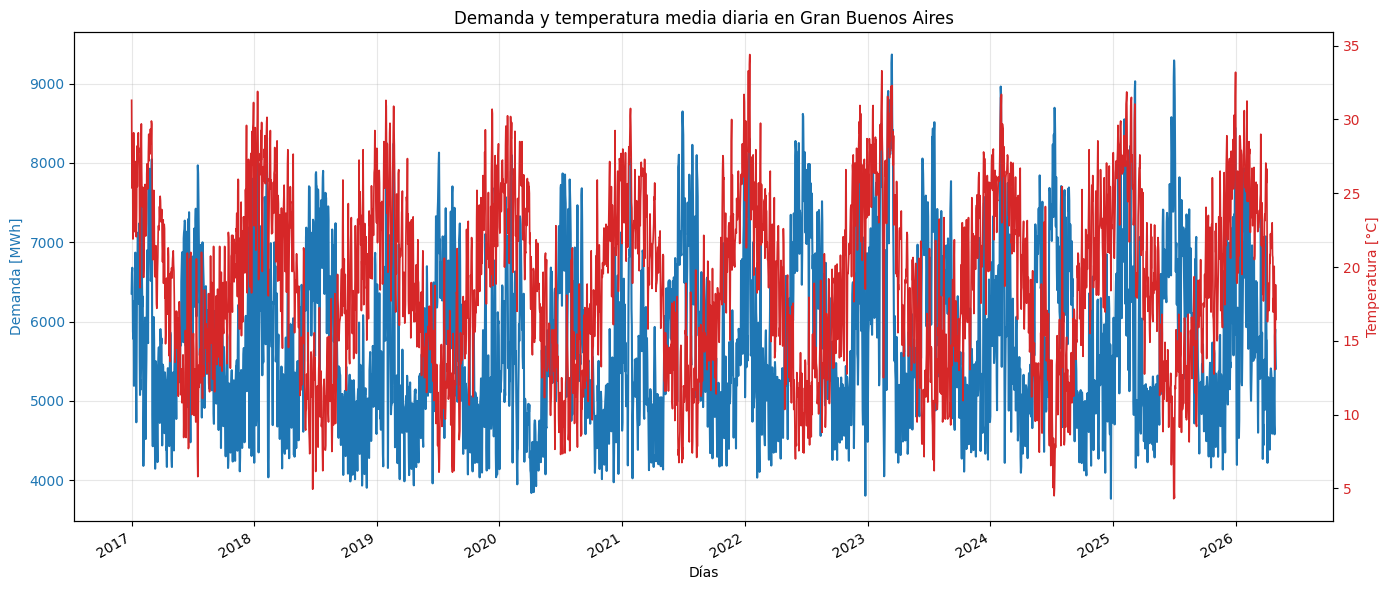

In [9]:
import matplotlib.pyplot as plt

# Se ordenan los datos para asegurar la secuencia temporal.
datos_grafico = demanda_gbsas.sort_values("fecha").dropna(subset=["fecha"])

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(datos_grafico["fecha"], datos_grafico["demanda"], color="tab:blue", linewidth=1.5)
ax2.plot(datos_grafico["fecha"], datos_grafico["temp_media"], color="tab:red", linewidth=1.2)

# Se asignan etiquetas y unidades a cada eje vertical.
ax1.set_xlabel("Días")
ax1.set_ylabel("Demanda [MWh]", color="tab:blue")
ax2.set_ylabel("Temperatura [°C]", color="tab:red")
ax1.set_title("Demanda y temperatura media diaria en Gran Buenos Aires")

ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


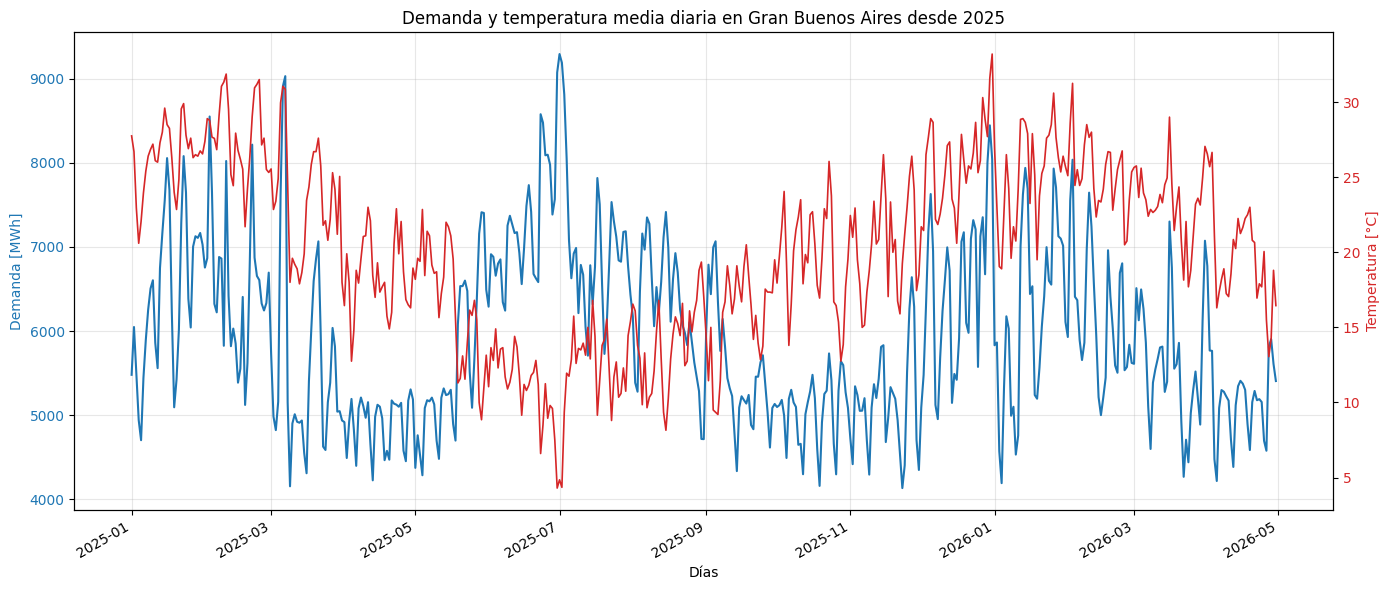

In [10]:
# Se filtran los datos desde enero de 2025 en adelante.
datos_grafico_2025 = demanda_gbsas.loc[
    demanda_gbsas["fecha"] >= pd.Timestamp("2025-01-01")
].sort_values("fecha")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(datos_grafico_2025["fecha"], datos_grafico_2025["demanda"], color="tab:blue", linewidth=1.5)
ax2.plot(datos_grafico_2025["fecha"], datos_grafico_2025["temp_media"], color="tab:red", linewidth=1.2)

# Se asignan etiquetas y unidades a cada eje vertical.
ax1.set_xlabel("Días")
ax1.set_ylabel("Demanda [MWh]", color="tab:blue")
ax2.set_ylabel("Temperatura [°C]", color="tab:red")
ax1.set_title("Demanda y temperatura media diaria en Gran Buenos Aires desde 2025")

ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Descomposición MSTL de la serie de demanda en GBA

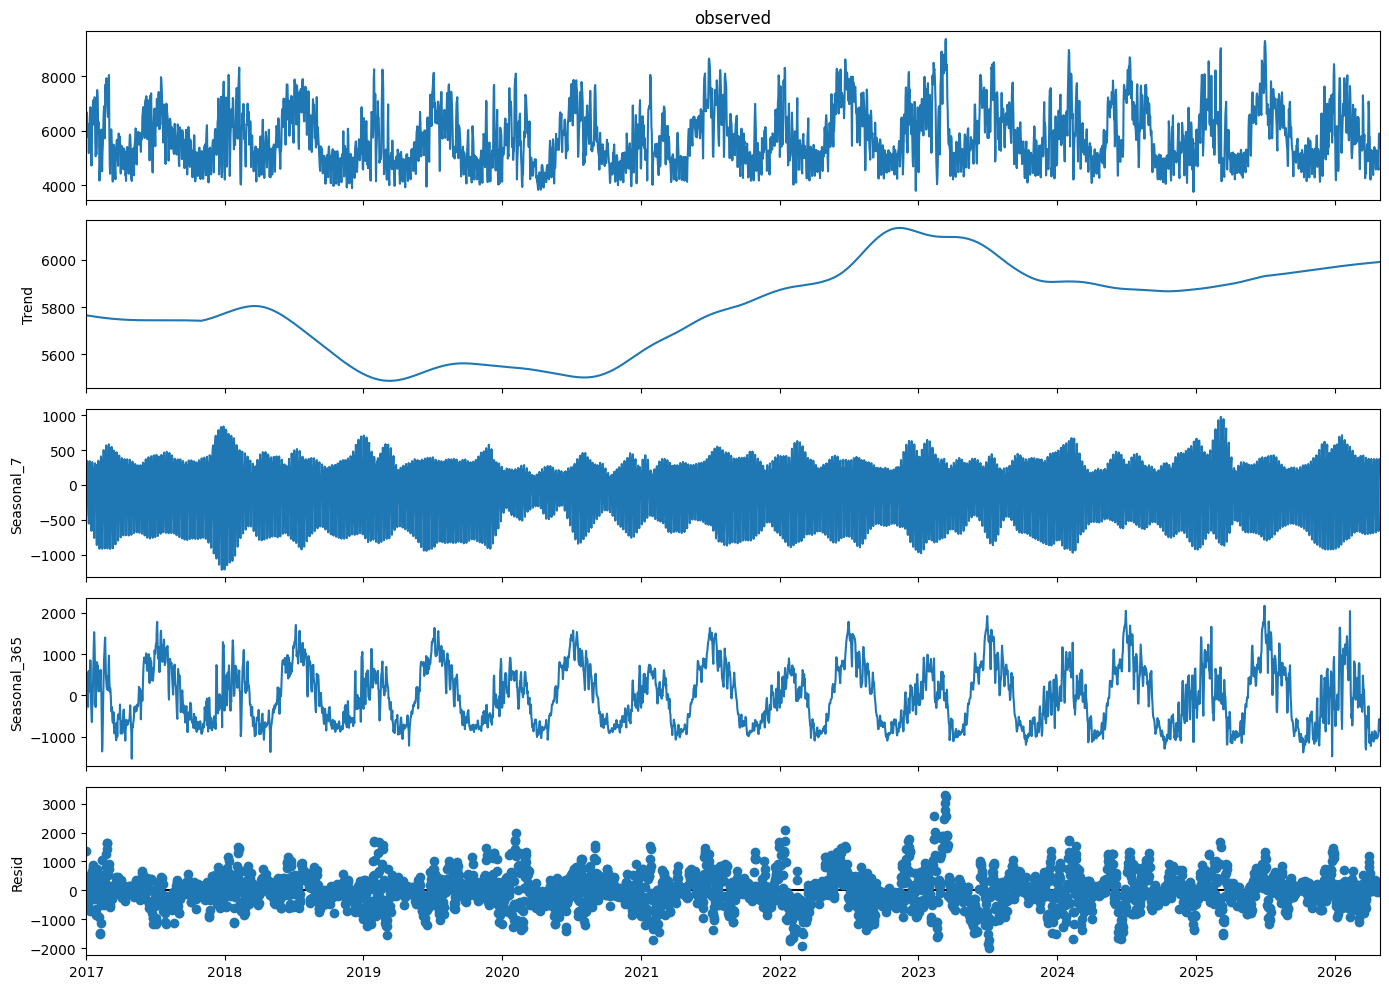

In [13]:
from statsmodels.tsa.seasonal import MSTL

# Se arma una serie diaria regular para la descomposición.
serie_mstl_demanda = (
    demanda_gbsas[["fecha", "demanda"]]
    .dropna(subset=["fecha", "demanda"])
    .drop_duplicates(subset="fecha")
    .sort_values("fecha")
    .set_index("fecha")["demanda"]
    .asfreq("D")
)

# Se completan faltantes temporales para sostener la frecuencia diaria.
serie_mstl_demanda = serie_mstl_demanda.interpolate(method="time").ffill().bfill()

mstl_demanda = MSTL(serie_mstl_demanda, periods=(7, 365))
resultado_mstl_demanda = mstl_demanda.fit()

fig = resultado_mstl_demanda.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


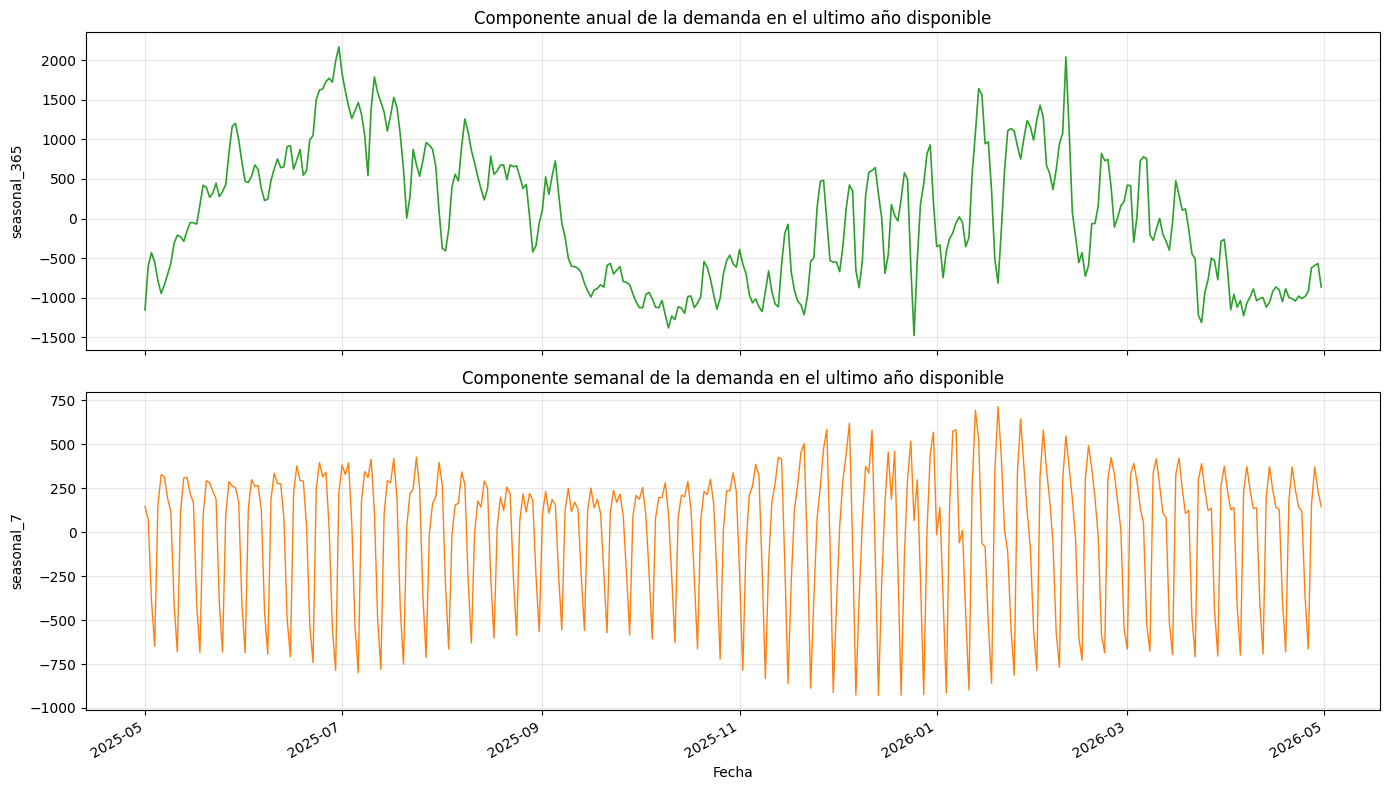

In [14]:
seasonal_mstl_demanda = resultado_mstl_demanda.seasonal.copy()
inicio_ultimo_anio = seasonal_mstl_demanda.index.max() - pd.Timedelta(days=364)
seasonal_mstl_ultimo_anio = seasonal_mstl_demanda.loc[inicio_ultimo_anio:]

# Se grafica un año para observar con mayor detalle las estacionalidades.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    seasonal_mstl_ultimo_anio.index,
    seasonal_mstl_ultimo_anio["seasonal_365"],
    color="tab:green",
    linewidth=1.2,
)
axes[0].set_ylabel("seasonal_365")
axes[0].set_title("Componente anual de la demanda en el ultimo año disponible")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    seasonal_mstl_ultimo_anio.index,
    seasonal_mstl_ultimo_anio["seasonal_7"],
    color="tab:orange",
    linewidth=1.0,
)
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("seasonal_7")
axes[1].set_title("Componente semanal de la demanda en el ultimo año disponible")
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### Análisis de la descomposición MSTL
La descomposición muestra dos patrones relevantes en la demanda. La componente anual presenta variaciones de gran amplitud, con valores positivos en torno a los meses de mayor demanda y valores negativos en períodos de menor contribución estacional. En este último año disponible, la señal anual no es perfectamente suave: aparecen oscilaciones y picos marcados, lo que insinúa que la estacionalidad anual está influida por eventos de corto plazo o por variabilidad no completamente separada por la descomposición.

La componente semanal es más clara y regular. Se observa un patrón repetitivo de período aproximado de 7 días, con caídas pronunciadas y recuperaciones sistemáticas dentro de cada semana. Esto evidencia que la demanda diaria tiene una estructura semanal fuerte, probablemente asociada a diferencias entre días hábiles y fines de semana.

En la tendencia, se observa una caída desde 2017 hasta aproximadamente 2019-2020, luego una recuperación marcada desde 2021, con un máximo alrededor de 2022-2023. Después parece bajar algo durante 2024 y volver a crecer suavemente hacia 2025-2026.

###  Prueba de estacionalidad ADF

In [15]:
from statsmodels.tsa.stattools import adfuller

# Se aplica la prueba ADF sobre la serie de demanda diaria regularizada.
resultado_adf = adfuller(serie_mstl_demanda.dropna(), autolag="AIC")

resumen_adf = pd.Series(
    {
        "estadistico_adf": resultado_adf[0],
        "p_value": resultado_adf[1],
        "lags_usados": resultado_adf[2],
        "n_observaciones": resultado_adf[3],
    }
)
valores_criticos_adf = pd.Series(resultado_adf[4], name="valor_critico")

display(resumen_adf.to_frame(name="valor"))
display(valores_criticos_adf.to_frame())

if resumen_adf["p_value"] < 0.05:
    print("Se rechaza la hipótesis nula de raíz unitaria al 5%.")
    print("La serie puede considerarse estacionaria bajo este contraste.")
else:
    print("No se rechaza la hipótesis nula de raíz unitaria al 5%.")
    print("La serie no puede considerarse estacionaria bajo este contraste.")


,valor
estadistico_adf,-6.153047e+00
p_value,7.481779e-08
lags_usados,2.900000e+01
n_observaciones,3.377000e+03


,valor_critico
1%,-3.432288
5%,-2.862396
10%,-2.567226


Se rechaza la hipótesis nula de raíz unitaria al 5%.
La serie puede considerarse estacionaria bajo este contraste.


### Análisis de la prueba de estacionalidad.
La prueba ADF aplicada a la serie de demanda diaria arrojó un estadístico de $−6.153$ y un p-value de $7.48×10^{−8}$. Dado que el p-value es menor que $0.05$, se rechaza la hipótesis nula. Por lo tanto, se cuenta con evidencia a favor de estacionariedad en nivel, por lo que inicialmente se considerará d=0 en la especificación SARIMA. No obstante, se realiza el análisis de autocorrelación para evaluar la presencia de estructura estacional semanal.